# 10 - Test-time tiny network phase map

This notebook compares three one-slice odd/even phase estimators on the saved scanner `.mat` file:

1. direct raw odd/even phase,
2. the traditional masked quadratic fit with smoothed residual from notebook `09`,
3. a tiny coordinate network trained at test time on this one sample.

The foreground mask and weights are the same simple algorithm used in `09_hand_by_hand_phase_map.ipynb`. The same weights are used for both the traditional circular quadratic fit and the tiny-network alignment loss.


In [9]:
import sys
import time
from pathlib import Path

import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path("/home/data1/musong/workspace/python/spen_recons")
sys.path.insert(0, str(ROOT / "spenpy"))

from spenpy.core import calcInvA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
print("device:", device)


device: cuda


In [10]:
mat_path = ROOT / "data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat"
mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

rofft_np = mat["spen_original_signal_rofft"]
if rofft_np.ndim == 3:
    rofft_np = rofft_np[:, :, None, :]

rofft = torch.as_tensor(rofft_np, dtype=torch.complex64, device=device)
spen_original = torch.as_tensor(mat["spen_original"], device=device)
params = mat["calc_inva_params"]

print("ROFFT shape [PE, RO, image, coil]:", tuple(rofft.shape))
print("spen_original shape:", tuple(spen_original.shape))


ROFFT shape [PE, RO, image, coil]: (96, 96, 1, 4)
spen_original shape: (96, 96)


In [11]:
def build_inva(args):
    args = torch.as_tensor(args, dtype=torch.float64).flatten()
    inv_a, _ = calcInvA(
        args[0], args[1], int(args[2].item()), args[3],
        int(args[4].item()), args[5], args[6],
    )
    return inv_a.to(device=device, dtype=torch.complex64)


def apply_pe_matrix(matrix, signal):
    return torch.einsum("ij,j...->i...", matrix, signal)


def rss_image_from_rofft(signal, inv_a):
    sr = apply_pe_matrix(inv_a, signal)
    return torch.sqrt(torch.sum(torch.abs(sr[:, :, 0, :]) ** 2, dim=-1))


def orient_for_display(image):
    return torch.flip(image, dims=(0, 1))


def display_abs(image, percentile=99.5):
    image = torch.abs(image).to(torch.float32)
    positive = image[image > 0]
    scale = torch.quantile(positive, percentile / 100.0).clamp_min(1e-8) if positive.numel() else image.new_tensor(1.0)
    return torch.clamp(image / scale, 0.0, 1.0)


def show(axis, image, title, cmap="gray", vmin=None, vmax=None):
    data = image.detach().cpu() if isinstance(image, torch.Tensor) else image
    im = axis.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set_title(title)
    axis.axis("off")
    plt.colorbar(im, ax=axis, fraction=0.046, pad=0.04)


def wrap_to_pi(x):
    return torch.atan2(torch.sin(x), torch.cos(x))


def sync_device():
    if device.type == "cuda":
        torch.cuda.synchronize()


def timed(fn):
    sync_device()
    start = time.perf_counter()
    out = fn()
    sync_device()
    return out, time.perf_counter() - start


In [12]:
inv_a = build_inva(params.full_args)
odd_inv = build_inva(params.odd_args)
even_inv = build_inva(params.even_args)

recon_before = rss_image_from_rofft(rofft, inv_a)

print("full InvA:", tuple(inv_a.shape))
print("odd InvA:", tuple(odd_inv.shape))
print("even InvA:", tuple(even_inv.shape))


full InvA: (96, 96)
odd InvA: (48, 48)
even InvA: (48, 48)


In [13]:
odd_sr = apply_pe_matrix(odd_inv, rofft[0::2])
even_sr = apply_pe_matrix(even_inv, rofft[1::2])

odd_img = odd_sr[:, :, 0, :]
even_img = even_sr[:, :, 0, :]
phase_cross = torch.sum(even_img * torch.conj(odd_img), dim=-1)
raw_phase = torch.angle(phase_cross).to(torch.float32)

odd_mag = torch.sqrt(torch.sum(torch.abs(odd_img) ** 2, dim=-1))
even_mag = torch.sqrt(torch.sum(torch.abs(even_img) ** 2, dim=-1))
min_mag = torch.minimum(odd_mag, even_mag)

mag_diff_std = torch.std(even_mag - odd_mag)
mag_mask = (odd_mag > 2.0 * mag_diff_std) & (even_mag > 2.0 * mag_diff_std)

strength = torch.abs(phase_cross)
strength_cutoff = torch.quantile(strength[mag_mask], 0.20) if torch.any(mag_mask) else strength.new_tensor(0.0)
mask = mag_mask & (strength >= strength_cutoff) & torch.isfinite(raw_phase)

weights = mask.to(torch.float32) * min_mag.to(torch.float32)
weights = weights / weights.max().clamp_min(1e-8)

height, width = raw_phase.shape
print("odd/even image shape:", tuple(raw_phase.shape))
print("mask fraction:", float(mask.to(torch.float32).mean().detach().cpu()))


odd/even image shape: (48, 96)
mask fraction: 0.2799479067325592


In [14]:
def normalized_coords(height, width, device, dtype=torch.float32):
    y = torch.linspace(-1.0, 1.0, height, device=device, dtype=dtype)
    x = torch.linspace(-1.0, 1.0, width, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    return torch.stack([xx, yy], dim=-1).reshape(-1, 2)


def quadratic_terms(height, width, device, dtype):
    coords = normalized_coords(height, width, device, dtype).reshape(height, width, 2)
    xx, yy = coords[..., 0], coords[..., 1]
    return torch.stack([torch.ones_like(xx), xx, yy, xx * xx, xx * yy, yy * yy], dim=-1)


def circular_mean(angle, weight):
    return torch.atan2(torch.sum(weight * torch.sin(angle)), torch.sum(weight * torch.cos(angle)))


def weighted_box_smooth(values, weights, kernel_size=11):
    pad = kernel_size // 2
    kernel = torch.ones((1, 1, kernel_size, kernel_size), dtype=values.dtype, device=values.device)
    numerator = F.conv2d((values * weights).unsqueeze(0).unsqueeze(0), kernel, padding=pad)
    denominator = F.conv2d(weights.unsqueeze(0).unsqueeze(0), kernel, padding=pad)
    return (numerator / denominator.clamp_min(1e-6)).squeeze(0).squeeze(0)


def fit_quadratic_phase(raw_phase, weights, max_iter=200):
    terms = quadratic_terms(height, width, raw_phase.device, raw_phase.dtype)
    design = terms.reshape(-1, 6)
    target = raw_phase.reshape(-1)
    weight = weights.reshape(-1)
    keep = torch.isfinite(target) & torch.isfinite(weight) & (weight > 0)

    if torch.count_nonzero(keep) < 6:
        raise RuntimeError("Not enough valid pixels for the 6-parameter phase fit.")

    design_fit = design[keep]
    target_fit = target[keep]
    weight_fit = weight[keep]

    coeffs = torch.zeros(6, dtype=raw_phase.dtype, device=raw_phase.device, requires_grad=True)
    coeffs.data[0] = circular_mean(target_fit, weight_fit)
    optimizer = torch.optim.LBFGS([coeffs], lr=0.8, max_iter=max_iter, line_search_fn="strong_wolfe")

    def closure():
        optimizer.zero_grad()
        model = design_fit @ coeffs
        loss = -torch.sum(weight_fit * torch.cos(target_fit - model)) / torch.sum(weight_fit)
        loss.backward()
        return loss

    optimizer.step(closure)
    coeffs = coeffs.detach()
    return coeffs, (design @ coeffs).reshape(height, width)


def fit_traditional_phase(raw_phase, weights, mask):
    coeffs, phase_poly = fit_quadratic_phase(raw_phase, weights)
    residual = wrap_to_pi(raw_phase - phase_poly)
    residual_smooth = weighted_box_smooth(residual, mask.to(torch.float32), kernel_size=11)
    return coeffs, phase_poly + residual_smooth


class TinyPhaseNet(nn.Module):
    def __init__(self, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, coords):
        return self.net(coords).squeeze(-1)


def corrected_even(phase_map):
    return even_img * torch.exp(-1j * phase_map[:, :, None])


def weighted_alignment_loss(phase_map, weights):
    cross = torch.sum(corrected_even(phase_map) * torch.conj(odd_img), dim=-1)
    phase_cos = torch.real(cross) / torch.abs(cross).clamp_min(1e-8)
    return 1.0 - torch.sum(weights * phase_cos) / torch.sum(weights).clamp_min(1e-8)


def weighted_abs_residual_phase(phase_map, weights):
    cross = torch.sum(corrected_even(phase_map) * torch.conj(odd_img), dim=-1)
    residual = torch.abs(torch.angle(cross))
    return torch.sum(weights * residual) / torch.sum(weights).clamp_min(1e-8)


def smoothness_loss(phase_map):
    dx = wrap_to_pi(phase_map[:, 1:] - phase_map[:, :-1])
    dy = wrap_to_pi(phase_map[1:, :] - phase_map[:-1, :])
    return dx.square().mean() + dy.square().mean()


def fit_tiny_network(weights, steps=500, hidden=8, lr=3e-2, smooth_weight=2e-3):
    coords = normalized_coords(height, width, device)
    model = TinyPhaseNet(hidden=hidden).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = []

    for step in range(steps + 1):
        optimizer.zero_grad(set_to_none=True)
        phase_map = model(coords).reshape(height, width)
        loss = weighted_alignment_loss(phase_map, weights) + smooth_weight * smoothness_loss(phase_map)
        loss.backward()
        optimizer.step()

        if step % 25 == 0 or step == steps:
            residual = weighted_abs_residual_phase(phase_map, weights)
            history.append((step, float(loss.detach().cpu()), float(residual.detach().cpu())))

    phase_map = model(coords).reshape(height, width).detach()
    num_params = sum(param.numel() for param in model.parameters())
    return phase_map, history, num_params


def reconstruct_with_phase(phase_map):
    corrected_rofft = rofft.clone()
    corrected_rofft[1::2] *= torch.exp(-1j * phase_map[:, :, None, None])
    return rss_image_from_rofft(corrected_rofft, inv_a)


In [15]:
(quad_coeffs, phase_traditional), traditional_time = timed(lambda: fit_traditional_phase(raw_phase, weights, mask))
(phase_net, net_history, net_params), net_time = timed(lambda: fit_tiny_network(weights))

methods = [
    {"name": "raw phase", "phase": raw_phase.detach(), "runtime_s": 0.0, "params": raw_phase.numel()},
    {"name": "traditional", "phase": phase_traditional.detach(), "runtime_s": traditional_time, "params": 6},
    {"name": "tiny net", "phase": phase_net.detach(), "runtime_s": net_time, "params": net_params},
]

for method in methods:
    method["recon"] = reconstruct_with_phase(method["phase"])
    method["residual_rad"] = float(weighted_abs_residual_phase(method["phase"], weights).detach().cpu())
    method["phase_min"] = float(method["phase"].min().detach().cpu())
    method["phase_max"] = float(method["phase"].max().detach().cpu())

print("quadratic coeffs:", quad_coeffs.detach().cpu())
for method in methods:
    print(
        f"{method['name']:>11s} | params={method['params']:>4} | "
        f"time={method['runtime_s']:.4f}s | weighted residual={method['residual_rad']:.4f} rad | "
        f"range=[{method['phase_min']:.3f}, {method['phase_max']:.3f}]"
    )


quadratic coeffs: tensor([-1.0659,  0.2257,  0.2300, -0.0323, -0.4783, -0.3780])
  raw phase | params=4608 | time=0.0000s | weighted residual=0.0000 rad | range=[-3.141, 3.136]
traditional | params=   6 | time=0.0805s | weighted residual=0.1447 rad | range=[-4.320, -0.036]
   tiny net | params= 105 | time=2.0888s | weighted residual=0.1452 rad | range=[-1.152, -0.785]


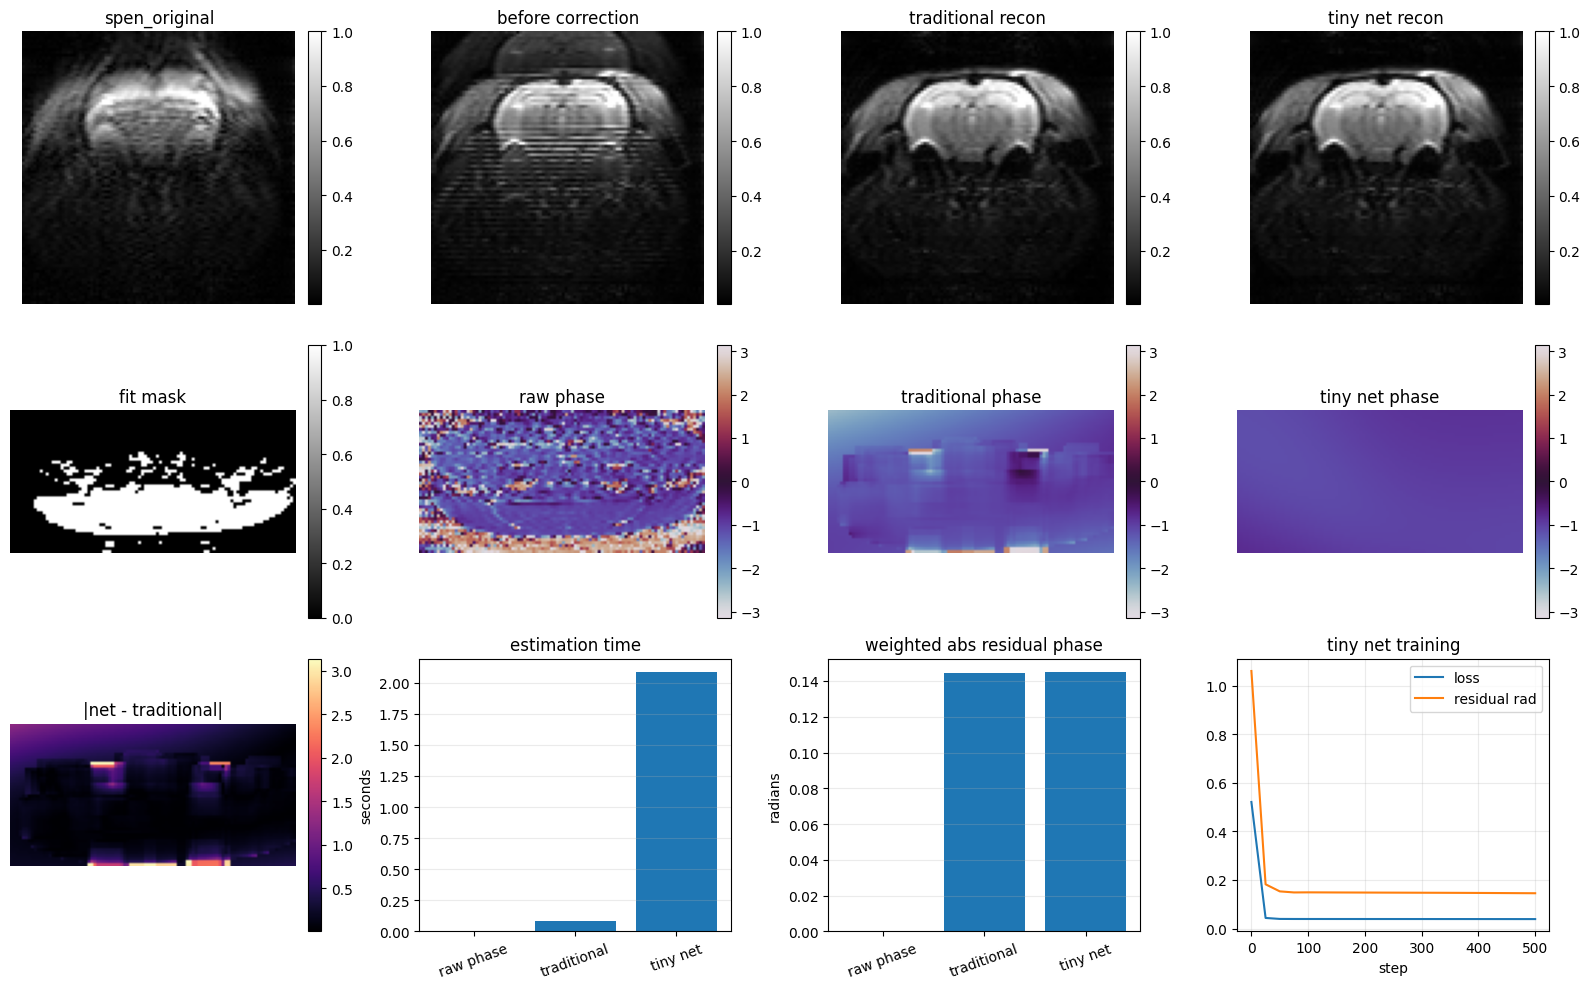

In [16]:
by_name = {method["name"]: method for method in methods}
labels = [method["name"] for method in methods]
times = [method["runtime_s"] for method in methods]
residuals = [method["residual_rad"] for method in methods]
steps = [item[0] for item in net_history]
losses = [item[1] for item in net_history]
net_residuals = [item[2] for item in net_history]

fig, ax = plt.subplots(3, 4, figsize=(16, 10))

show(ax[0, 0], display_abs(spen_original), "spen_original")
show(ax[0, 1], display_abs(orient_for_display(recon_before)), "before correction")
show(ax[0, 2], display_abs(orient_for_display(by_name["traditional"]["recon"])), "traditional recon")
show(ax[0, 3], display_abs(orient_for_display(by_name["tiny net"]["recon"])), "tiny net recon")

show(ax[1, 0], mask.to(torch.float32), "fit mask", "gray", 0.0, 1.0)
show(ax[1, 1], wrap_to_pi(by_name["raw phase"]["phase"]), "raw phase", "twilight", -torch.pi, torch.pi)
show(ax[1, 2], wrap_to_pi(by_name["traditional"]["phase"]), "traditional phase", "twilight", -torch.pi, torch.pi)
show(ax[1, 3], wrap_to_pi(by_name["tiny net"]["phase"]), "tiny net phase", "twilight", -torch.pi, torch.pi)

show(ax[2, 0], torch.abs(wrap_to_pi(by_name["tiny net"]["phase"] - by_name["traditional"]["phase"])), "|net - traditional|", "magma")

ax[2, 1].bar(labels, times)
ax[2, 1].set_title("estimation time")
ax[2, 1].set_ylabel("seconds")
ax[2, 1].tick_params(axis="x", rotation=20)
ax[2, 1].grid(True, axis="y", alpha=0.25)

ax[2, 2].bar(labels, residuals)
ax[2, 2].set_title("weighted abs residual phase")
ax[2, 2].set_ylabel("radians")
ax[2, 2].tick_params(axis="x", rotation=20)
ax[2, 2].grid(True, axis="y", alpha=0.25)

ax[2, 3].plot(steps, losses, label="loss")
ax[2, 3].plot(steps, net_residuals, label="residual rad")
ax[2, 3].set_title("tiny net training")
ax[2, 3].set_xlabel("step")
ax[2, 3].grid(True, alpha=0.25)
ax[2, 3].legend()

plt.tight_layout()


## What is fitted?

The raw phase method estimates one phase value per pixel directly from `angle(even * conj(odd))`, so it has a dense `(48, 96)` map and no smoothness model.

The traditional method fits 6 quadratic coefficients with the `09` mask/weights, then adds the same masked smoothed residual used in `09`.

The tiny network fits its MLP weights at test time on this one slice, using the same `09` mask/weights in its odd/even phase-alignment loss. With `hidden=8`, that is 105 scalar parameters, then the trained network is evaluated on the full `(48, 96)` coordinate grid.
